# Download document for knowledge base

In [1]:
import torch
print(torch.__version__)
print(torch.version.cuda)

2.6.0+cu124
12.4


In [2]:
# !pip3 install --no-cache-dir flash-attn  --no-build-isolation --break-system-packages # once after docker build

In [6]:
# Download PDF file
import os
import requests

# Get PDF document- Knowledge Base
pdf_path = "sample_insurance_policy.pdf"

# Download PDF if it doesn't already exist
if not os.path.exists(pdf_path):
  print("File doesn't exist, downloading...")

  # The URL of the PDF for the RAG Knowledge Base demo
  # url = "https://healthsourceri.com/wp-content/uploads/2016/11/Principal-Sample-Life-Insurance-Policy.pdf"
  url ="https://hahf.org/wp-content/uploads/media-5/sample-insurance-policy.pdf"

  # The local filename to save the downloaded file
  filename = pdf_path

  # Send a GET request to the URL
  response = requests.get(url)

  # Check if the request was successful
  if response.status_code == 200:
      # Open a file in binary write mode and save the content to it
      with open(filename, "wb") as file:
          file.write(response.content)
      print(f"The file has been downloaded and saved as {filename}")
  else:
      print(f"Failed to download the file. Status code: {response.status_code}")
else:
  print(f"File {pdf_path} exists.")

File doesn't exist, downloading...
The file has been downloaded and saved as sample_insurance_policy.pdf


In [7]:
# Requires !pip install PyMuPDF, see: https://github.com/pymupdf/pymupdf
import fitz # (pymupdf, found this is better than pypdf for our use case, note: licence is AGPL-3.0, keep that in mind if you want to use any code commercially)
from tqdm.auto import tqdm # for progress bars, requires !pip install tqdm 

def text_formatter(text: str) -> str:
    """Performs minor formatting on text."""
    cleaned_text = text.replace("\n", " ").strip() # note: this might be different for each doc (best to experiment)

    # Other potential text formatting functions can go here
    return cleaned_text

# Open PDF and get lines/pages
# Note: this only focuses on text, rather than images/figures etc
def open_and_read_pdf(pdf_path: str) -> list[dict]:
    """
    Opens a PDF file, reads its text content page by page, and collects statistics.

    Parameters:
        pdf_path (str): The file path to the PDF document to be opened and read.

    Returns:
        list[dict]: A list of dictionaries, each containing the page number
        (adjusted), character count, word count, sentence count, token count, and the extracted text
        for each page.
    """
    doc = fitz.open(pdf_path)  # open a document
    pages_and_texts = []
    for page_number, page in tqdm(enumerate(doc)):  # iterate the document pages
        text = page.get_text()  # get plain text encoded as UTF-8
        text = text_formatter(text)
        pages_and_texts.append({"page_number": page_number - 41,  # adjust page numbers since our PDF starts on page 42
                                "page_char_count": len(text),
                                "page_word_count": len(text.split(" ")),
                                "page_sentence_count_raw": len(text.split(". ")),
                                "page_token_count": len(text) / 4,  # 1 token = ~4 chars, see: https://help.openai.com/en/articles/4936856-what-are-tokens-and-how-to-count-them
                                "text": text})
    return pages_and_texts

pages_and_texts = open_and_read_pdf(pdf_path=pdf_path)
pages_and_texts[:2]

/opt/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
21it [00:00, 181.86it/s]


[{'page_number': -41,
  'page_char_count': 1143,
  'page_word_count': 330,
  'page_sentence_count_raw': 10,
  'page_token_count': 285.75,
  'text': 'UNITED STATES FIRE INSURANCE COMPANY  Administrative Offices:  5 Christopher Way  •  Eatontown,  NJ  07724  BLANKET BENEFITS  ACCIDENT ONLY POLICY        Policy Number:  US151741  Policyholder:   School District of Hillsborough County    P.O. Box 3408    Tampa, FL 33601    Policy Effective Date:  August 1, 2013  Policy Expiration Date:  August 1, 2014    This Policy is issued in the state of Florida and shall be governed by its laws.    This Policy contains the terms under which the Insurance Company agrees to insure certain persons and pay  benefits.    The Insurance Company and the Policyholder have agreed to all the terms of this Policy.      THIS IS AN ACCIDENT ONLY POLICY AND CONTAINS  DEDUCTIBLE AND EXCESS INSURANCE PROVISIONS.    PLEASE READ IT CAREFULLY.    BENEFITS ARE NOT PAYABLE FOR LOSS DUE TO SICKNESS.    THIS POLICY PAYS BENE

In [8]:
import random

random.sample(pages_and_texts, k=3)

[{'page_number': -25,
  'page_char_count': 3942,
  'page_word_count': 690,
  'page_sentence_count_raw': 27,
  'page_token_count': 985.5,
  'text': 'When used throughout this document “The Company”, “Our”, “We”, or “Us”  means:  United States Fire Insurance Company                                PRIVACY  POLICY  AND  PRACTICES    The Company values your business and your trust.  In order to administer insurance policies and provide  you with effective customer service, we must collect certain information about our customers.  We want  you to know that we are committed to protecting your private information and we will comply with all  federal and state privacy laws.  Below is a Privacy Notice describing our policy regarding the collection  and disclosure of personal information.  Please review this Notice and keep a copy of it with your  records.  Your Privacy is Our Concern  When you apply to The Company for insurance or make a claim against a policy written by The Company, you  disclo

In [9]:
import pandas as pd

df = pd.DataFrame(pages_and_texts)
df.head()

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,text
0,-41,1143,330,10,285.75,UNITED STATES FIRE INSURANCE COMPANY Administ...
1,-40,364,102,1,91.00,TABLE OF CONTENTS Page Number Schedu...
2,-39,1786,475,3,446.50,SCHEDULE OF BENEFITS BENEFIT PERIOD: 1 Yea...
3,-38,2195,389,8,548.75,Maximum Benefit: URC Anesthesia Maximum Bene...
4,-37,2863,501,16,715.75,DEFINITIONS The terms shown below shall hav...


In [10]:
# Get stats
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count
count,21.0,21.00,21.00,21.00,21.00
mean,-31.0,2634.90,488.48,14.95,658.73
std,6.2,1036.57,169.92,7.79,259.14
min,-41.0,107.00,23.00,1.00,26.75
25%,-36.0,2518.00,458.00,10.00,629.50
50%,-31.0,2853.00,529.00,16.00,713.25
75%,-26.0,3327.00,587.00,19.00,831.75
max,-21.0,3942.00,690.00,30.00,985.50


In [11]:
from spacy.lang.en import English # see https://spacy.io/usage for install instructions

nlp = English()

# Add a sentencizer pipeline, see https://spacy.io/api/sentencizer/ 
nlp.add_pipe("sentencizer")

# Create a document instance as an example
doc = nlp("This is a sentence. This another sentence.")
assert len(list(doc.sents)) == 2

# Access the sentences of the document
list(doc.sents)

[This is a sentence., This another sentence.]

In [12]:
for item in tqdm(pages_and_texts):
    item["sentences"] = list(nlp(item["text"]).sents)
    
    # Make sure all sentences are strings
    item["sentences"] = [str(sentence) for sentence in item["sentences"]]
    
    # Count the sentences 
    item["page_sentence_count_spacy"] = len(item["sentences"])

100%|██████████████████████████████████████████████████████████████████████████████████| 21/21 [00:00<00:00, 251.02it/s]


In [13]:
# Inspect an example
random.sample(pages_and_texts, k=1)

[{'page_number': -29,
  'page_char_count': 3327,
  'page_word_count': 551,
  'page_sentence_count_raw': 24,
  'page_token_count': 831.75,
  'text': '11. Practice or play in any sports activity, including travel to and from the activity and practice, unless  specifically provided for in this Policy;  12. Expenses to the extent that they are paid or payable under other valid and collectible group insurance or  medical prepayment plan;  13. Blood or Blood plasma, except for charges by a Hospital for the processing or administration of blood;  14. Elective treatment or surgery, health treatment, or examination where no Injury is involved;  15. Injury sustained while in the service of the armed forces of any country.  When the Covered Person  enters the armed forces of any country, We will refund the unearned pro rata premium upon request;  16. Eyeglasses, contact lenses, hearing aids, braces, appliances, or examinations or prescriptions therefore;  17. Treatment in any Veterans Administrat

In [14]:
df = pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,page_sentence_count_spacy
count,21.0,21.00,21.00,21.00,21.00,21.00
mean,-31.0,2634.90,488.48,14.95,658.73,14.62
std,6.2,1036.57,169.92,7.79,259.14,7.48
min,-41.0,107.00,23.00,1.00,26.75,1.00
25%,-36.0,2518.00,458.00,10.00,629.50,11.00
50%,-31.0,2853.00,529.00,16.00,713.25,16.00
75%,-26.0,3327.00,587.00,19.00,831.75,19.00
max,-21.0,3942.00,690.00,30.00,985.50,30.00


In [15]:
# Define split size to turn groups of sentences into chunks
num_sentence_chunk_size = 10 

# Create a function that recursively splits a list into desired sizes
def split_list(input_list: list, 
               slice_size: int) -> list[list[str]]:
    """
    Splits the input_list into sublists of size slice_size (or as close as possible).

    For example, a list of 17 sentences would be split into two lists of [[10], [7]]
    """
    return [input_list[i:i + slice_size] for i in range(0, len(input_list), slice_size)]

# Loop through pages and texts and split sentences into chunks
for item in tqdm(pages_and_texts):
    item["sentence_chunks"] = split_list(input_list=item["sentences"],
                                         slice_size=num_sentence_chunk_size)
    item["num_chunks"] = len(item["sentence_chunks"])

100%|███████████████████████████████████████████████████████████████████████████████| 21/21 [00:00<00:00, 179389.78it/s]


In [16]:
# Sample an example from the group (note: many samples have only 1 chunk as they have <=10 sentences total)
random.sample(pages_and_texts, k=1)

[{'page_number': -39,
  'page_char_count': 1786,
  'page_word_count': 475,
  'page_sentence_count_raw': 3,
  'page_token_count': 446.5,
  'text': 'SCHEDULE OF BENEFITS    BENEFIT PERIOD:  1 Year from the date of an Injury, provided care  continues to be Medically Necessary    PREMIUM:  $3.75 (Day Care)    $3.50 (Summer)    $7.50 (Community Based Trianing)  DEDUCTIBLE AMOUNT:  $0.00  COINSURANCE PERCENTAGE:  100% of Usual, Reasonable & Customary Charges,  URC  MAXIMUM BENEFIT AMOUNT:  $25,000.00  Hospital Inpatient Room and Board:                     $200.00 Per Day  Hospital Outpatient Expense, Emergency Room: $185.00 Per Injury  Physician’s Expense (Non-Surgical):                   $40.00 Per Visit  Physician’s Expense (Surgical):                         $3,750.00 Per Injury  Diagnostic Imaging:                            $400.00 Per Injury  Physiotherapy:                              $35.00 Per Visit, 5 Visit Maximum        Prescription Drugs:                                         

In [17]:
# Create a DataFrame to get stats
df = pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,page_sentence_count_spacy,num_chunks
count,21.0,21.00,21.00,21.00,21.00,21.00,21.00
mean,-31.0,2634.90,488.48,14.95,658.73,14.62,1.90
std,6.2,1036.57,169.92,7.79,259.14,7.48,0.62
min,-41.0,107.00,23.00,1.00,26.75,1.00,1.00
25%,-36.0,2518.00,458.00,10.00,629.50,11.00,2.00
50%,-31.0,2853.00,529.00,16.00,713.25,16.00,2.00
75%,-26.0,3327.00,587.00,19.00,831.75,19.00,2.00
max,-21.0,3942.00,690.00,30.00,985.50,30.00,3.00


In [18]:
import re

# Split each chunk into its own item
pages_and_chunks = []
for item in tqdm(pages_and_texts):
    for sentence_chunk in item["sentence_chunks"]:
        chunk_dict = {}
        chunk_dict["page_number"] = item["page_number"]
        
        # Join the sentences together into a paragraph-like structure, aka a chunk (so they are a single string)
        joined_sentence_chunk = "".join(sentence_chunk).replace("  ", " ").strip()
        joined_sentence_chunk = re.sub(r'\.([A-Z])', r'. \1', joined_sentence_chunk) # ".A" -> ". A" for any full-stop/capital letter combo 
        chunk_dict["sentence_chunk"] = joined_sentence_chunk

        # Get stats about the chunk
        chunk_dict["chunk_char_count"] = len(joined_sentence_chunk)
        chunk_dict["chunk_word_count"] = len([word for word in joined_sentence_chunk.split(" ")])
        chunk_dict["chunk_token_count"] = len(joined_sentence_chunk) / 4 # 1 token = ~4 characters
        
        pages_and_chunks.append(chunk_dict)

# How many chunks do we have?
len(pages_and_chunks)

100%|█████████████████████████████████████████████████████████████████████████████████| 21/21 [00:00<00:00, 9358.31it/s]


40

In [19]:
# View a random sample
random.sample(pages_and_chunks, k=1)

[{'page_number': -36,
  'sentence_chunk': 'Sickness includes normal pregnancy and complications of pregnancy. All related conditions and recurring symptoms of sickness to the same person will be considered one sickness. "Supervised or Sponsored Activity" means an authorized function by a Policyholder or School: (1) In which the Covered Person participates; (2) Which is organized by or under its auspices; and (3) Which is within the scope of customary activities for such entity.  "Usual, Reasonable and Customary (“U&C”) means: (1) With respect to fees or charges, fees for medical services or supplies which are; (a) Usually charged by the provider for the service or supply given; and (b) The average charged for the service or supply in the locality in which the service or supply is received; or  (2) With respect to treatment or medical services, treatment which is reasonable in relationship to the service or supply given and the severity of the condition.  GAP 26932-FL 6 Policy',
  'chun

In [20]:
# Get stats about our chunks
df = pd.DataFrame(pages_and_chunks)
df.describe().round(2)

,page_number,chunk_char_count,chunk_word_count,chunk_token_count
count,40.00,40.00,40.00,40.00
mean,-30.02,1350.92,224.52,337.73
std,5.58,622.48,102.44,155.62
min,-41.00,97.00,16.00,24.25
25%,-34.25,992.75,161.75,248.19
50%,-29.50,1289.50,219.50,322.38
75%,-25.75,1696.00,304.00,424.00
max,-21.00,2638.00,426.00,659.50


In [22]:
# Show random chunks with under 30 tokens in length
# min_token_length = 30
# for row in df[df["chunk_token_count"] <= min_token_length].sample(5).iterrows():
#     print(f'Chunk token count: {row[1]["chunk_token_count"]} | Text: {row[1]["sentence_chunk"]}')

subset = df[df["chunk_token_count"] <= min_token_length]

for row in subset.sample(min(5, len(subset))).iterrows():
    print(f'Chunk token count: {row[1]["chunk_token_count"]} | Text: {row[1]["sentence_chunk"]}')

Chunk token count: 25.0 | Text: GAP 26932-FL 18 Policy Fairmont Speciality  5 Christopher Way, 3rd Floor Eatontown, New Jersey 07724
Chunk token count: 24.25 | Text: Loss  Percentage of Principal Sum Loss of Life 100% Loss of Both Hands 100% GAP 26932-FL 8 Policy


In [23]:
pages_and_chunks_over_min_token_len = df[df["chunk_token_count"] > min_token_length].to_dict(orient="records")
pages_and_chunks_over_min_token_len[:2]

[{'page_number': -41,
  'sentence_chunk': 'UNITED STATES FIRE INSURANCE COMPANY Administrative Offices: 5 Christopher Way • Eatontown, NJ 07724 BLANKET BENEFITS ACCIDENT ONLY POLICY    Policy Number: US151741 Policyholder:  School District of Hillsborough County  P. O. Box 3408  Tampa, FL 33601  Policy Effective Date: August 1, 2013 Policy Expiration Date: August 1, 2014  This Policy is issued in the state of Florida and shall be governed by its laws.  This Policy contains the terms under which the Insurance Company agrees to insure certain persons and pay benefits.  The Insurance Company and the Policyholder have agreed to all the terms of this Policy.   THIS IS AN ACCIDENT ONLY POLICY AND CONTAINS DEDUCTIBLE AND EXCESS INSURANCE PROVISIONS.  PLEASE READ IT CAREFULLY.  BENEFITS ARE NOT PAYABLE FOR LOSS DUE TO SICKNESS.  THIS POLICY PAYS BENEFITS FOR SPECIFIC LOSSES FROM ACCIDENT ONLY.   Signed for The United States Fire Insurance Company By:              Douglas M. Libby James Kraus  

In [36]:
# Requires !pip install sentence-transformers
from sentence_transformers import SentenceTransformer

# TO DO authenticate requests to huggingface

embedding_model = SentenceTransformer(model_name_or_path="all-mpnet-base-v2", 
                                      device="cpu") # choose the device to load the model to (note: GPU will often be *much* faster than CPU)

# Create a list of sentences to turn into numbers
sentences = [
    "The Sentences Transformers library provides an easy and open-source way to create embeddings.",
    "Sentences can be embedded individually or as a list of strings.",
    "Embeddings are a powerful concept in machine learning"
]

# Sentences are encoded/embedded by calling model.encode()
embeddings = embedding_model.encode(sentences)
embeddings_dict = dict(zip(sentences, embeddings))

# See the embeddings
for sentence, embedding in embeddings_dict.items():
    print("Sentence:", sentence)
    print("Length Embedding:", len(embedding))
    print("")

Loading weights: 100%|██████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 3314.02it/s]


Sentence: The Sentences Transformers library provides an easy and open-source way to create embeddings.
Length Embedding: 768

Sentence: Sentences can be embedded individually or as a list of strings.
Length Embedding: 768

Sentence: Embeddings are a powerful concept in machine learning
Length Embedding: 768



# create knowledge-base embeddings

In [27]:
%%time

# Send the model to the GPU
embedding_model.to("cuda") # requires a GPU installed, for reference on my local machine, I'm using a NVIDIA RTX 4090

# Create embeddings one by one on the GPU
for item in tqdm(pages_and_chunks_over_min_token_len):
    item["embedding"] = embedding_model.encode(item["sentence_chunk"])

100%|███████████████████████████████████████████████████████████████████████████████████| 38/38 [00:01<00:00, 20.92it/s]

CPU times: user 4.65 s, sys: 1.04 s, total: 5.69 s
Wall time: 2.15 s


In [28]:
# Turn text chunks into a single list
text_chunks = [item["sentence_chunk"] for item in pages_and_chunks_over_min_token_len]

In [29]:
%%time

# Embed all texts in batches
text_chunk_embeddings = embedding_model.encode(text_chunks,
                                               batch_size=32, # you can use different batch sizes here for speed/performance, I found 32 works well for this use case
                                               convert_to_tensor=True) # optional to return embeddings as tensor instead of array

text_chunk_embeddings

CPU times: user 1.56 s, sys: 35 ms, total: 1.6 s
Wall time: 1.29 s


tensor([[-0.0448,  0.0642,  0.0133,  ..., -0.0045, -0.0336, -0.0269],
        [-0.0209,  0.0123, -0.0090,  ..., -0.0046,  0.0231, -0.0183],
        [-0.0161,  0.0131, -0.0030,  ..., -0.0165, -0.0082, -0.0273],
        ...,
        [ 0.0219,  0.0130, -0.0096,  ...,  0.0126, -0.0923, -0.0097],
        [ 0.0401,  0.0055,  0.0035,  ...,  0.0140, -0.0662,  0.0005],
        [ 0.0436,  0.0012, -0.0225,  ...,  0.0454, -0.0882, -0.0079]],
       device='cuda:0')

In [30]:
# Save embeddings to file
text_chunks_and_embeddings_df = pd.DataFrame(pages_and_chunks_over_min_token_len)
embeddings_df_save_path = "text_chunks_and_embeddings_df.csv"
text_chunks_and_embeddings_df.to_csv(embeddings_df_save_path, index=False)

In [31]:
# Import saved file and view
text_chunks_and_embedding_df_load = pd.read_csv(embeddings_df_save_path)
text_chunks_and_embedding_df_load.head()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count,embedding
0,-41,UNITED STATES FIRE INSURANCE COMPANY Administr...,1039,226,259.75,[-4.47906740e-02 6.41952753e-02 1.32543389e-...
1,-40,TABLE OF CONTENTS Page Number Schedule of ...,323,61,80.75,[-2.09418479e-02 1.22734569e-02 -8.98363255e-...
2,-39,SCHEDULE OF BENEFITS BENEFIT PERIOD: 1 Year f...,1630,319,407.50,[-1.60512123e-02 1.31252697e-02 -3.04831471e-...
3,-38,Maximum Benefit: URC Anesthesia Maximum Benefi...,2131,325,532.75,[ 1.94646530e-02 3.50938067e-02 6.48881192e-...
4,-37,DEFINITIONS The terms shown below shall have ...,1293,208,323.25,[-4.16890271e-02 -4.38769907e-02 5.52165788e-...


# RAG

In [60]:
import random

import torch
import numpy as np 
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"

# Import texts and embedding df
text_chunks_and_embedding_df = pd.read_csv("text_chunks_and_embeddings_df.csv")

# Convert embedding column back to np.array (it got converted to string when it got saved to CSV)
text_chunks_and_embedding_df["embedding"] = text_chunks_and_embedding_df["embedding"].apply(lambda x: np.fromstring(x.strip("[]"), sep=" "))

# Convert texts and embedding df to list of dicts
pages_and_chunks = text_chunks_and_embedding_df.to_dict(orient="records")

# Convert embeddings to torch tensor and send to device (note: NumPy arrays are float64, torch tensors are float32 by default)
embeddings = torch.tensor(np.array(text_chunks_and_embedding_df["embedding"].tolist()), dtype=torch.float32).to(device)
embeddings.shape

torch.Size([38, 768])

In [61]:
len(text_chunks_and_embedding_df)

38

In [62]:
text_chunks_and_embedding_df.head()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count,embedding
0,-41,UNITED STATES FIRE INSURANCE COMPANY Administr...,1039,226,259.75,"[-0.044790674, 0.0641952753, 0.0132543389, -0...."
1,-40,TABLE OF CONTENTS Page Number Schedule of ...,323,61,80.75,"[-0.0209418479, 0.0122734569, -0.00898363255, ..."
2,-39,SCHEDULE OF BENEFITS BENEFIT PERIOD: 1 Year f...,1630,319,407.50,"[-0.0160512123, 0.0131252697, -0.00304831471, ..."
3,-38,Maximum Benefit: URC Anesthesia Maximum Benefi...,2131,325,532.75,"[0.019464653, 0.0350938067, 0.000648881192, -0..."
4,-37,DEFINITIONS The terms shown below shall have ...,1293,208,323.25,"[-0.0416890271, -0.0438769907, 0.00552165788, ..."


In [63]:
len(embeddings[0])

768

In [64]:
from sentence_transformers import util, SentenceTransformer

embedding_model = SentenceTransformer(model_name_or_path="all-mpnet-base-v2", 
                                      device=device) # choose the device to load the model to

Loading weights: 100%|██████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 3511.84it/s]


#  query embedding / knowledge-base embedding dot product comparison

In [70]:
# 1. Define the query
# Note: This could be anything. But since we're working with a nutrition textbook, we'll stick with nutrition-based queries.
query = "Hi, I submitted a claim for a $3,800 emergency room visit and ambulance transport \
after my son fractured his wrist during a school-sponsored baseball tournament in another state. \
The insurance only reimbursed about $1,900. The Explanation of Benefits says part of the ambulance charge was \
considered non-covered and that coinsurance and deductible were applied. We also submitted follow-up physiotherapy visits,\
but two sessions were denied. Can you explain exactly why these charges were reduced or denied under my policy,\
whether the out-of-state treatment affected coverage, and if the denied physiotherapy sessions can be appealed?"
print(f"Query: {query}")

# 2. Embed the query to the same numerical space as the text examples 
# Note: It's important to embed your query with the same model you embedded your examples with.
query_embedding = embedding_model.encode(query, convert_to_tensor=True)

# 3. Get similarity scores with the dot product (we'll time this for fun)
from time import perf_counter as timer

start_time = timer()
dot_scores = util.dot_score(a=query_embedding, b=embeddings)[0]
end_time = timer()

print(f"Time take to get scores on {len(embeddings)} embeddings: {end_time-start_time:.5f} seconds.")

# 4. Get the top-k results (we'll keep this to 3)
top_results_dot_product = torch.topk(dot_scores, k=5)
top_results_dot_product

Query: Hi, I submitted a claim for a $3,800 emergency room visit and ambulance transport after my son fractured his wrist during a school-sponsored baseball tournament in another state. The insurance only reimbursed about $1,900. The Explanation of Benefits says part of the ambulance charge was considered non-covered and that coinsurance and deductible were applied. We also submitted follow-up physiotherapy visits,but two sessions were denied. Can you explain exactly why these charges were reduced or denied under my policy,whether the out-of-state treatment affected coverage, and if the denied physiotherapy sessions can be appealed?
Time take to get scores on 38 embeddings: 0.00019 seconds.


torch.return_types.topk(
values=tensor([0.6674, 0.6492, 0.6485, 0.6460, 0.6286], device='cuda:0'),
indices=tensor([ 8, 14, 21,  4,  2], device='cuda:0'))

In [71]:
dot_scores.shape

torch.Size([38])

In [72]:
embeddings.shape, len(query_embedding)

(torch.Size([38, 768]), 768)

In [73]:
larger_embeddings = torch.randn(100*embeddings.shape[0], 768).to(device)
print(f"Embeddings shape: {larger_embeddings.shape}")

# Perform dot product across 168,000 embeddings
start_time = timer()

device = "cuda" if torch.cuda.is_available() else "cpu"

query_embedding = query_embedding.to(device)
larger_embeddings = larger_embeddings.to(device)

dot_scores = util.dot_score(a=query_embedding, b=larger_embeddings)[0]
end_time = timer()

print(f"Time take to get scores on {len(larger_embeddings)} embeddings: {end_time-start_time:.5f} seconds.")

Embeddings shape: torch.Size([3800, 768])
Time take to get scores on 3800 embeddings: 0.00503 seconds.


In [74]:
# Define helper function to print wrapped text 
import textwrap

def print_wrapped(text, wrap_length=80):
    wrapped_text = textwrap.fill(text, wrap_length)
    print(wrapped_text)

In [75]:
print(f"Query: '{query}'\n")
print("Results:")
# Loop through zipped together scores and indicies from torch.topk
for score, idx in zip(top_results_dot_product[0], top_results_dot_product[1]):
    print(f"Score: {score:.4f}")
    # Print relevant sentence chunk (since the scores are in descending order, the most relevant chunk will be first)
    print("Text:")
    print_wrapped(pages_and_chunks[idx]["sentence_chunk"])
    # Print the page number too so we can reference the textbook further (and check the results)
    print(f"Page number: {pages_and_chunks[idx]['page_number']}")
    print("\n")

Query: 'Hi, I submitted a claim for a $3,800 emergency room visit and ambulance transport after my son fractured his wrist during a school-sponsored baseball tournament in another state. The insurance only reimbursed about $1,900. The Explanation of Benefits says part of the ambulance charge was considered non-covered and that coinsurance and deductible were applied. We also submitted follow-up physiotherapy visits,but two sessions were denied. Can you explain exactly why these charges were reduced or denied under my policy,whether the out-of-state treatment affected coverage, and if the denied physiotherapy sessions can be appealed?'

Results:
Score: 0.6674
Text:
SCOPE OF COVERAGE We will provide the benefits described in this Policy to all
Covered Persons who suffer a covered loss which: (1) Is within the scope of the
DESCRIPTION OF BENEFITS PROVISIONS; and results, directly and independently of
all other causes, from bodily Injury which is suffered in an Accident; and (2)
Occurs whi

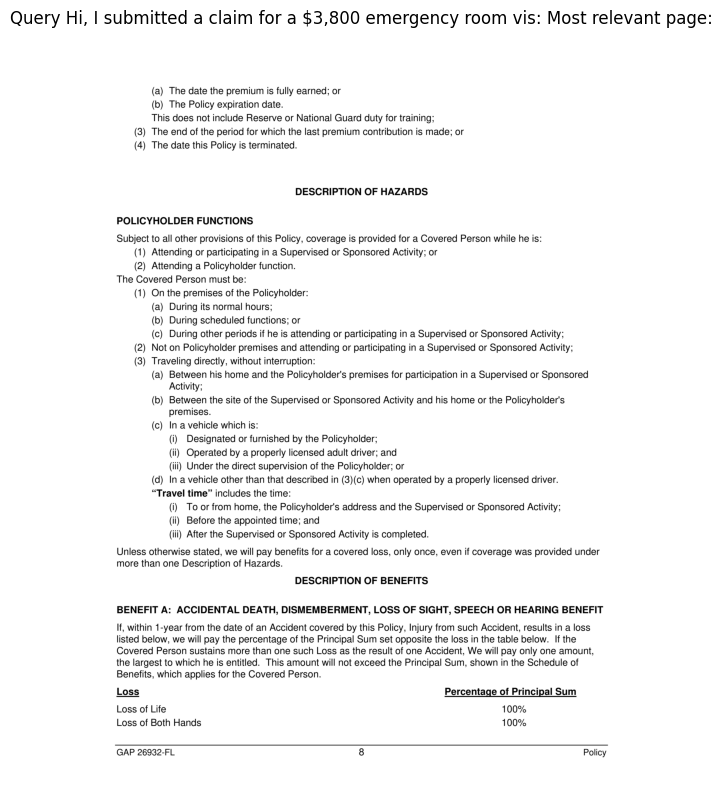

In [79]:
import fitz

# Open PDF and load target page
pdf_path = "sample_insurance_policy.pdf" # requires PDF to be downloaded
doc = fitz.open(pdf_path)
page = doc.load_page(-35) # number of page with max similarity to query (found in cell above)

# Get the image of the page
img = page.get_pixmap(dpi=300)

# Optional: save the image
#img.save("output_filename.png")
doc.close()

# Convert the Pixmap to a numpy array
img_array = np.frombuffer(img.samples_mv, 
                          dtype=np.uint8).reshape((img.h, img.w, img.n))

# Display the image using Matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(13, 10))
plt.imshow(img_array)
plt.title(f"Query {query[0:55]}: Most relevant page:")
plt.axis('off') # Turn off axis
plt.show()

In [53]:
import torch

def dot_product(vector1, vector2):
    return torch.dot(vector1, vector2)

def cosine_similarity(vector1, vector2):
    dot_product = torch.dot(vector1, vector2)

    # Get Euclidean/L2 norm of each vector (removes the magnitude, keeps direction)
    norm_vector1 = torch.sqrt(torch.sum(vector1**2))
    norm_vector2 = torch.sqrt(torch.sum(vector2**2))

    return dot_product / (norm_vector1 * norm_vector2)

# Example tensors
vector1 = torch.tensor([1, 2, 3], dtype=torch.float32)
vector2 = torch.tensor([1, 2, 3], dtype=torch.float32)
vector3 = torch.tensor([4, 5, 6], dtype=torch.float32)
vector4 = torch.tensor([-1, -2, -3], dtype=torch.float32)

# Calculate dot product
print("Dot product between vector1 and vector2:", dot_product(vector1, vector2))
print("Dot product between vector1 and vector3:", dot_product(vector1, vector3))
print("Dot product between vector1 and vector4:", dot_product(vector1, vector4))

# Calculate cosine similarity
print("Cosine similarity between vector1 and vector2:", cosine_similarity(vector1, vector2))
print("Cosine similarity between vector1 and vector3:", cosine_similarity(vector1, vector3))
print("Cosine similarity between vector1 and vector4:", cosine_similarity(vector1, vector4))

Dot product between vector1 and vector2: tensor(14.)
Dot product between vector1 and vector3: tensor(32.)
Dot product between vector1 and vector4: tensor(-14.)
Cosine similarity between vector1 and vector2: tensor(1.0000)
Cosine similarity between vector1 and vector3: tensor(0.9746)
Cosine similarity between vector1 and vector4: tensor(-1.0000)


In [80]:
def retrieve_relevant_resources(query: str,
                                embeddings: torch.tensor,
                                model: SentenceTransformer=embedding_model,
                                n_resources_to_return: int=5,
                                print_time: bool=True):
    """
    Embeds a query with model and returns top k scores and indices from embeddings.
    """

    # Embed the query
    query_embedding = model.encode(query, 
                                   convert_to_tensor=True) 

    # Get dot product scores on embeddings
    start_time = timer()
    dot_scores = util.dot_score(query_embedding, embeddings)[0]
    end_time = timer()

    if print_time:
        print(f"[INFO] Time taken to get scores on {len(embeddings)} embeddings: {end_time-start_time:.5f} seconds.")

    scores, indices = torch.topk(input=dot_scores, 
                                 k=n_resources_to_return)

    return scores, indices

def print_top_results_and_scores(query: str,
                                 embeddings: torch.tensor,
                                 pages_and_chunks: list[dict]=pages_and_chunks,
                                 n_resources_to_return: int=5):
    """
    Takes a query, retrieves most relevant resources and prints them out in descending order.

    Note: Requires pages_and_chunks to be formatted in a specific way (see above for reference).
    """
    
    scores, indices = retrieve_relevant_resources(query=query,
                                                  embeddings=embeddings,
                                                  n_resources_to_return=n_resources_to_return)
    
    print(f"Query: {query}\n")
    print("Results:")
    # Loop through zipped together scores and indicies
    for score, index in zip(scores, indices):
        print(f"Score: {score:.4f}")
        # Print relevant sentence chunk (since the scores are in descending order, the most relevant chunk will be first)
        print_wrapped(pages_and_chunks[index]["sentence_chunk"])
        # Print the page number too so we can reference the textbook further and check the results
        print(f"Page number: {pages_and_chunks[index]['page_number']}")
        print("\n")

In [81]:
query = "injury at work"

# Get just the scores and indices of top related results
scores, indices = retrieve_relevant_resources(query=query,
                                              embeddings=embeddings)
scores, indices

[INFO] Time taken to get scores on 38 embeddings: 0.00014 seconds.


(tensor([0.5156, 0.4786, 0.4421, 0.4417, 0.4250], device='cuda:0'),
 tensor([14,  6, 18, 11,  4], device='cuda:0'))

In [82]:
# Print out the texts of the top scores
print_top_results_and_scores(query=query,
                             embeddings=embeddings)

[INFO] Time taken to get scores on 38 embeddings: 0.00007 seconds.
Query: injury at work

Results:
Score: 0.5156
(9) Physiotherapy - Charges for physiotherapy: (a) While Hospital confined, up
to the Maximum Benefit Amount shown in the Schedule of Benefits for the Hospital
Inpatient Physiotherapy benefit; (b) As an outpatient, up to the Maximum Benefit
Amount shown on the Schedule of Benefits for the Outpatient Physiotherapy
benefit. Physiotherapy includes: (a) Heat treatment; (b) Diathermy; (c)
Microtherm; (d) Ultrasonic; (e) Adjustment; (f) Manipulation; (g) Massage
therapy and (h) Acupuncture. Total treatment per Injury will not exceed the
Physiotherapy Maximums shown in the Schedule of Benefits.  (10)Ambulance - from
the place where the Injury occurred to the Hospital, up to the Maximum Benefit
Amount shown in the Schedule of Benefits for the Ambulance benefit.  (11)Medical
Equipment Rental - charges for medical equipment for: (a) A wheelchair; (b) An
iron lung; or GAP 26932-FL 10 P

# check GPU memory

In [83]:
# Get GPU available memory
import torch
gpu_memory_bytes = torch.cuda.get_device_properties(0).total_memory
gpu_memory_gb = round(gpu_memory_bytes / (2**30))
print(f"Available GPU memory: {gpu_memory_gb} GB")

Available GPU memory: 8 GB


In [84]:
# Note: the following is Gemma focused, however, there are more and more LLMs of the 2B and 7B size appearing for local use.
if gpu_memory_gb < 5.1:
    print(f"Your available GPU memory is {gpu_memory_gb}GB, you may not have enough memory to run a Gemma LLM locally without quantization.")
elif gpu_memory_gb < 8.1:
    print(f"GPU memory: {gpu_memory_gb} | Recommended model: Gemma 2B in 4-bit precision.")
    use_quantization_config = True 
    model_id = "google/gemma-2b-it"
elif gpu_memory_gb < 19.0:
    print(f"GPU memory: {gpu_memory_gb} | Recommended model: Gemma 2B in float16 or Gemma 7B in 4-bit precision.")
    use_quantization_config = False 
    model_id = "google/gemma-2b-it"
elif gpu_memory_gb > 19.0:
    print(f"GPU memory: {gpu_memory_gb} | Recommend model: Gemma 7B in 4-bit or float16 precision.")
    use_quantization_config = False 
    model_id = "google/gemma-7b-it"

print(f"use_quantization_config set to: {use_quantization_config}")
print(f"model_id set to: {model_id}")

GPU memory: 8 | Recommended model: Gemma 2B in 4-bit precision.
use_quantization_config set to: True
model_id set to: google/gemma-2b-it


# Load LLM Locally

In [86]:
from huggingface_hub import login

In [87]:
login("...")

In [89]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.utils import is_flash_attn_2_available 

# 1. Create quantization config for smaller model loading (optional)
# Requires !pip install bitsandbytes accelerate, see: https://github.com/TimDettmers/bitsandbytes, https://huggingface.co/docs/accelerate/
# For models that require 4-bit quantization (use this if you have low GPU memory available)
from transformers import BitsAndBytesConfig
quantization_config = BitsAndBytesConfig(load_in_4bit=True,
                                         bnb_4bit_compute_dtype=torch.float16)

# Bonus: Setup Flash Attention 2 for faster inference, default to "sdpa" or "scaled dot product attention" if it's not available
# Flash Attention 2 requires NVIDIA GPU compute capability of 8.0 or above, see: https://developer.nvidia.com/cuda-gpus
# Requires !pip install flash-attn, see: https://github.com/Dao-AILab/flash-attention 
# if (is_flash_attn_2_available()) and (torch.cuda.get_device_capability(0)[0] >= 8):
#   attn_implementation = "flash_attention_2"
# else:
#   attn_implementation = "sdpa"
attn_implementation = "sdpa"

print(f"[INFO] Using attention implementation: {attn_implementation}")

# 2. Pick a model we'd like to use (this will depend on how much GPU memory you have available)
#model_id = "google/gemma-7b-it"
model_id = model_id # (we already set this above)
print(f"[INFO] Using model_id: {model_id}")

# 3. Instantiate tokenizer (tokenizer turns text into numbers ready for the model) 
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path=model_id)

# 4. Instantiate the model
llm_model = AutoModelForCausalLM.from_pretrained(pretrained_model_name_or_path=model_id, 
                                                 torch_dtype=torch.float16, # datatype to use, we want float16
                                                 quantization_config=quantization_config if use_quantization_config else None,
                                                 low_cpu_mem_usage=False, # use full memory 
                                                 attn_implementation=attn_implementation) # which attention version to use

if not use_quantization_config: # quantization takes care of device setting automatically, so if it's not used, send model to GPU 
    llm_model.to("cuda")

[INFO] Using attention implementation: sdpa
[INFO] Using model_id: google/gemma-2b-it


Loading weights: 100%|████████████████████████████████████████████████████████████████| 164/164 [00:02<00:00, 64.12it/s]


In [90]:
llm_model

GemmaForCausalLM(
  (model): GemmaModel(
    (embed_tokens): GemmaTextScaledWordEmbedding(256000, 2048, padding_idx=0)
    (layers): ModuleList(
      (0-17): 18 x GemmaDecoderLayer(
        (self_attn): GemmaAttention(
          (q_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear4bit(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear4bit(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): GemmaMLP(
          (gate_proj): Linear4bit(in_features=2048, out_features=16384, bias=False)
          (up_proj): Linear4bit(in_features=2048, out_features=16384, bias=False)
          (down_proj): Linear4bit(in_features=16384, out_features=2048, bias=False)
          (act_fn): GELUActivation()
        )
        (input_layernorm): GemmaRMSNorm((2048,), eps=1e-06)
        (post_attention_layernorm): GemmaRMSNorm((2048,), eps=1e-06)
 

In [91]:
def get_model_num_params(model: torch.nn.Module):
    return sum([param.numel() for param in model.parameters()])

get_model_num_params(llm_model)

1515268096

In [92]:
def get_model_mem_size(model: torch.nn.Module):
    """
    Get how much memory a PyTorch model takes up.

    See: https://discuss.pytorch.org/t/gpu-memory-that-model-uses/56822
    """
    # Get model parameters and buffer sizes
    mem_params = sum([param.nelement() * param.element_size() for param in model.parameters()])
    mem_buffers = sum([buf.nelement() * buf.element_size() for buf in model.buffers()])

    # Calculate various model sizes
    model_mem_bytes = mem_params + mem_buffers # in bytes
    model_mem_mb = model_mem_bytes / (1024**2) # in megabytes
    model_mem_gb = model_mem_bytes / (1024**3) # in gigabytes

    return {"model_mem_bytes": model_mem_bytes,
            "model_mem_mb": round(model_mem_mb, 2),
            "model_mem_gb": round(model_mem_gb, 2)}

get_model_mem_size(llm_model)

{'model_mem_bytes': 2039632898, 'model_mem_mb': 1945.15, 'model_mem_gb': 1.9}

In [94]:
input_text = "I had outpatient knee surgery after a sports injury and submitted claims \
for the procedure, crutches, and six physical therapy visits. The insurance covered the surgery \
but denied two therapy sessions and only partially reimbursed the medical equipment. \
Can you explain which benefits, deductibles, or exclusions applied under my policy?"
print(f"Input text:\n{input_text}")

# Create prompt template for instruction-tuned model
dialogue_template = [
    {"role": "user",
     "content": input_text}
]

# Apply the chat template
prompt = tokenizer.apply_chat_template(conversation=dialogue_template,
                                       tokenize=False, # keep as raw text (not tokenized)
                                       add_generation_prompt=True)
print(f"\nPrompt (formatted):\n{prompt}")

Input text:
I had outpatient knee surgery after a sports injury and submitted claims for the procedure, crutches, and six physical therapy visits. The insurance covered the surgery but denied two therapy sessions and only partially reimbursed the medical equipment. Can you explain which benefits, deductibles, or exclusions applied under my policy?

Prompt (formatted):
<bos><start_of_turn>user
I had outpatient knee surgery after a sports injury and submitted claims for the procedure, crutches, and six physical therapy visits. The insurance covered the surgery but denied two therapy sessions and only partially reimbursed the medical equipment. Can you explain which benefits, deductibles, or exclusions applied under my policy?<end_of_turn>
<start_of_turn>model



In [95]:
%%time

# Tokenize the input text (turn it into numbers) and send it to GPU
input_ids = tokenizer(prompt, return_tensors="pt").to("cuda")
print(f"Model input (tokenized):\n{input_ids}\n")

# Generate outputs passed on the tokenized input
# See generate docs: https://huggingface.co/docs/transformers/v4.38.2/en/main_classes/text_generation#transformers.GenerationConfig 
outputs = llm_model.generate(**input_ids,
                             max_new_tokens=256) # define the maximum number of new tokens to create
print(f"Model output (tokens):\n{outputs[0]}\n")

Model input (tokenized):
{'input_ids': tensor([[     2,      2,    106,   1645,    108, 235285,   1093, 102506,  22644,
          15505,   1452,    476,   9028,  11585,    578,  13623,  10861,    604,
            573,  10286, 235269, 201995, 235269,    578,   4442,   6915,  13414,
          20635, 235265,    714,   9490,   8758,    573,  15505,    901,  17732,
           1378,  13414,  16567,    578,   1297,  26711, 159423,    573,   6910,
           6682, 235265,   2551,    692,  10200,    948,   7839, 235269,  25087,
         137891, 235269,    689, 161285,   7936,   1362,    970,   5075, 235336,
            107,    108,    106,   2516,    108]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]],
       device='cuda:0')}

Model output (tokens):
tensor([     2,      2,  

In [96]:
# Decode the output tokens to text
outputs_decoded = tokenizer.decode(outputs[0])
print(f"Model output (decoded):\n{outputs_decoded}\n")

Model output (decoded):
<bos><bos><start_of_turn>user
I had outpatient knee surgery after a sports injury and submitted claims for the procedure, crutches, and six physical therapy visits. The insurance covered the surgery but denied two therapy sessions and only partially reimbursed the medical equipment. Can you explain which benefits, deductibles, or exclusions applied under my policy?<end_of_turn>
<start_of_turn>model
**Benefits:**

* Surgery to repair or replace damaged joint or tissue
* Medications to relieve pain and inflammation
* Physical therapy to help regain mobility and strength

**Deductibles:**

* The amount you must pay out-of-pocket before your insurance starts covering the costs.
* Deductibles vary depending on your policy, but they are typically around 20% of the total cost of the service.

**Exclusions:**

* The surgery itself is typically not covered by insurance.
* Rehabilitation sessions that are not medically necessary or not approved by your insurance company a

In [97]:
print(f"Input text: {input_text}\n")
print(f"Output text:\n{outputs_decoded.replace(prompt, '').replace('<bos>', '').replace('<eos>', '')}")

Input text: I had outpatient knee surgery after a sports injury and submitted claims for the procedure, crutches, and six physical therapy visits. The insurance covered the surgery but denied two therapy sessions and only partially reimbursed the medical equipment. Can you explain which benefits, deductibles, or exclusions applied under my policy?

Output text:
**Benefits:**

* Surgery to repair or replace damaged joint or tissue
* Medications to relieve pain and inflammation
* Physical therapy to help regain mobility and strength

**Deductibles:**

* The amount you must pay out-of-pocket before your insurance starts covering the costs.
* Deductibles vary depending on your policy, but they are typically around 20% of the total cost of the service.

**Exclusions:**

* The surgery itself is typically not covered by insurance.
* Rehabilitation sessions that are not medically necessary or not approved by your insurance company are not covered.
* Certain medical conditions or preexisting co

In [100]:
gpt4_questions = [
    "Why was my emergency room claim only partially reimbursed?",
    "Does my policy require prior authorization for outpatient surgery?",
    "Why were two of my physical therapy visits denied?",
    "Is ambulance transportation covered under my accident policy?",
    "How does my deductible and coinsurance affect claim reimbursement?"
]

# Manually created question list
manual_questions = [
    "Does this plan cover out-of-state treatment?",
    "Why was my prescription claim rejected?",
    "What documents are needed to appeal a denied claim?",
    "Does this procedure count toward my out-of-pocket maximum?",
    "How long does claims processing usually take?"
]

query_list = gpt4_questions + manual_questions

In [101]:
import random
query = random.choice(query_list)

print(f"Query: {query}")

# Get just the scores and indices of top related results
scores, indices = retrieve_relevant_resources(query=query,
                                              embeddings=embeddings)
scores, indices

Query: Why was my prescription claim rejected?
[INFO] Time taken to get scores on 38 embeddings: 0.00016 seconds.


(tensor([0.4989, 0.4882, 0.4679, 0.4190, 0.3905], device='cuda:0'),
 tensor([34, 15, 37, 36, 32], device='cuda:0'))

In [102]:
def prompt_formatter(query: str, 
                     context_items: list[dict]) -> str:
    """
    Augments query with text-based context from context_items.
    """
    # Join context items into one dotted paragraph
    context = "- " + "\n- ".join([item["sentence_chunk"] for item in context_items])

    # Create a base prompt with examples to help the model
    # Note: this is very customizable, I've chosen to use 3 examples of the answer style we'd like.
    # We could also write this in a txt file and import it in if we wanted.
    base_prompt = """Based on the following context items, please answer the query.
Give yourself room to think by extracting relevant passages from the context before answering the query.
Don't return the thinking, only return the answer.
Make sure your answers are as explanatory as possible.
Use the following examples as reference for the ideal answer style.
\nExample 1:
Query: Why was my emergency room claim only partially reimbursed?
Answer: Emergency room claims are often reduced because deductibles, \
coinsurance, non-covered charges, or out-of-network provider fees may apply under the policy.\
For example, if the member had not yet met their annual deductible, part of the bill would remain the patient’s responsibility.\
Additionally, certain charges such as ambulance transportation, physician fees, or non-emergency services may be reimbursed at different rates\
depending on the policy terms. Reviewing the Explanation of Benefits (EOB) and the emergency care section of the policy can clarify exactly\
which adjustments were applied.

Example 2:
Query: Why were two of my physical therapy visits denied?
Answer: Physical therapy visits may be denied if the policy imposes visit limits,\
requires prior authorization, or determines that additional treatment was not medically necessary.\
Some plans only cover a fixed number of therapy sessions per injury or calendar year, while others require\
updated physician documentation after a certain number of visits. Claims may also be denied if the therapy provider\
was outside the approved network or if required referral documentation was missing at the time of claim submission.

Example 3:
Query: Does my policy require prior authorization for outpatient surgery?
Answer: Many insurance policies require prior authorization for outpatient surgical procedures to confirm medical necessity\
before treatment occurs. Prior authorization helps the insurance provider evaluate whether the procedure meets coverage guidelines \
and whether alternative treatments should be considered first. If authorization was not obtained before the surgery, the claim could be\
partially reduced or denied depending on the policy rules. Members are typically encouraged to contact their provider or \
insurance support team before scheduling non-emergency procedures to verify authorization requirements.
{context}
\nRelevant passages: <extract relevant passages from the context here>
User query: {query}
Answer:"""

    # Update base prompt with context items and query   
    base_prompt = base_prompt.format(context=context, query=query)

    # Create prompt template for instruction-tuned model
    dialogue_template = [
        {"role": "user",
        "content": base_prompt}
    ]

    # Apply the chat template
    prompt = tokenizer.apply_chat_template(conversation=dialogue_template,
                                          tokenize=False,
                                          add_generation_prompt=True)
    return prompt

In [103]:
query = random.choice(query_list)
print(f"Query: {query}")

# Get relevant resources
scores, indices = retrieve_relevant_resources(query=query,
                                              embeddings=embeddings)
    
# Create a list of context items
context_items = [pages_and_chunks[i] for i in indices]

# Format prompt with context items
prompt = prompt_formatter(query=query,
                          context_items=context_items)
print(prompt)

Query: How long does claims processing usually take?
[INFO] Time taken to get scores on 38 embeddings: 0.00010 seconds.
<bos><start_of_turn>user
Based on the following context items, please answer the query.
Give yourself room to think by extracting relevant passages from the context before answering the query.
Don't return the thinking, only return the answer.
Make sure your answers are as explanatory as possible.
Use the following examples as reference for the ideal answer style.

Example 1:
Query: Why was my emergency room claim only partially reimbursed?
Answer: Emergency room claims are often reduced because deductibles, coinsurance, non-covered charges, or out-of-network provider fees may apply under the policy.For example, if the member had not yet met their annual deductible, part of the bill would remain the patient’s responsibility.Additionally, certain charges such as ambulance transportation, physician fees, or non-emergency services may be reimbursed at different ratesdepe

In [104]:
%%time

input_ids = tokenizer(prompt, return_tensors="pt").to("cuda")

# Generate an output of tokens
outputs = llm_model.generate(**input_ids,
                             temperature=0.7, # lower temperature = more deterministic outputs, higher temperature = more creative outputs
                             do_sample=True, # whether or not to use sampling, see https://huyenchip.com/2024/01/16/sampling.html for more
                             max_new_tokens=256) # how many new tokens to generate from prompt 

# Turn the output tokens into text
output_text = tokenizer.decode(outputs[0])

print(f"Query: {query}")
print(f"RAG answer:\n{output_text.replace(prompt, '')}")

Query: How long does claims processing usually take?
RAG answer:
<bos>The context does not provide any information about how long claims processing usually takes, so I cannot answer this question from the provided context.<eos>
CPU times: user 1.25 s, sys: 156 ms, total: 1.41 s
Wall time: 1.41 s


In [105]:
def ask(query, 
        temperature=0.7,
        max_new_tokens=512,
        format_answer_text=True, 
        return_answer_only=True):
    """
    Takes a query, finds relevant resources/context and generates an answer to the query based on the relevant resources.
    """
    
    # Get just the scores and indices of top related results
    scores, indices = retrieve_relevant_resources(query=query,
                                                  embeddings=embeddings)
    
    # Create a list of context items
    context_items = [pages_and_chunks[i] for i in indices]

    # Add score to context item
    for i, item in enumerate(context_items):
        item["score"] = scores[i].cpu() # return score back to CPU 
        
    # Format the prompt with context items
    prompt = prompt_formatter(query=query,
                              context_items=context_items)
    
    # Tokenize the prompt
    input_ids = tokenizer(prompt, return_tensors="pt").to("cuda")

    # Generate an output of tokens
    outputs = llm_model.generate(**input_ids,
                                 temperature=temperature,
                                 do_sample=True,
                                 max_new_tokens=max_new_tokens)
    
    # Turn the output tokens into text
    output_text = tokenizer.decode(outputs[0])

    if format_answer_text:
        # Replace special tokens and unnecessary help message
        output_text = output_text.replace(prompt, "").replace("<bos>", "").replace("<eos>", "").replace("Sure, here is the answer to the user query:\n\n", "")

    # Only return the answer without the context items
    if return_answer_only:
        return output_text
    
    return output_text, context_items

In [106]:
query = random.choice(query_list)
print(f"Query: {query}")

# Answer query with context and return context 
answer, context_items = ask(query=query, 
                            temperature=0.7,
                            max_new_tokens=512,
                            return_answer_only=False)

print(f"Answer:\n")
print_wrapped(answer)
print(f"Context items:")
context_items

Query: How long does claims processing usually take?
[INFO] Time taken to get scores on 38 embeddings: 0.00008 seconds.
Answer:

The context does not provide any information about the length of claims
processing, so I cannot answer this question from the context.
Context items:


[{'page_number': -27,
  'sentence_chunk': "If claim forms are not sent within 15 days after notice is given, the proof requirements will be met by submitting, within the time required under PROOF OF LOSS, written proof of the nature and extent of the loss. PROOF OF LOSS: Written proof of loss must be furnished to us in the case of a claim for loss for which this Policy provides periodic payment contingent upon continuing loss within 90 days after the end of the period for which we are liable. Written proof that the loss continues must be furnished to us at intervals required by us. In case of claim for any other loss, proof must be furnished within 90 days after the date of such loss. If that is not reasonably possible, we will not deny or reduce any claim if proof is furnished as soon as reasonably possible. Proof must, in any case, be furnished not more than one year later, except for lack of legal capacity. TIME OF PAYMENT OF CLAIMS: Benefits due under this Policy for a loss, other 